In [298]:
# Cell 1：掛載 Google Drive
#using google colab drive open
#from google.colab import drive
#drive.mount('/content/drive')
## 不使用google.drive 這段要註解

In [299]:
# Cell 2：匯入套件
import os
import csv
import time
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


print("1411262011_謝晨佑")

1411262011_謝晨佑


In [300]:
# Cell 3：路徑設定 + 自動下載
import os

NPZ_PATH = "/content/drive/MyDrive/Colab Notebooks/data/printed_chars_dataset.npz"

RESULT_DIR = "/content/drive/MyDrive/Colab Notebooks/results"

### 不使用google.drive掛載 的 路徑設置 。例如使用 github gist
if not os.path.exists('/content/drive'):
    BASE_DIR = "/content"
    os.makedirs(BASE_DIR + "/data", exist_ok=True)
    NPZ_PATH = os.path.join(BASE_DIR, "data/printed_chars_dataset.npz") ## 另一筆資料， 檔名..dataset_simple.npz
    RESULT_DIR = os.path.join(BASE_DIR, "results")
###
os.makedirs(RESULT_DIR, exist_ok=True)

RESULT_TXT = os.path.join(RESULT_DIR, "result_lenet.txt")
RESULT_CSV = os.path.join(RESULT_DIR, "result_lenet.csv")

# 自動下載
if not os.path.exists(NPZ_PATH):
    print("找不到 npz，開始下載...")
    !pip install -q gdown
    import gdown

    file_id = "1OuK9eYrdlXuYl_kbjMy27dW7dgzEnL3_"
    url = f"https://drive.google.com/uc?id={file_id}"
    #url = "https://drive.google.com/file/d/1xx3UOeD2W9hUJBYT6fKOdkwW-TT0uJIj"  #另一筆資料#

    gdown.download(url, NPZ_PATH, quiet=False)
else:
    print("已找到 npz")

已找到 npz


In [301]:
# Cell 4：讀取資料
data = np.load(NPZ_PATH, allow_pickle=True)

images = data["images"]       # (N, 28, 28)
labels = data["labels"]
label_names = data["label_names"]

print(images.shape, labels.shape)


# Cell 4-2: 資料整理 (數字0跟字母o合併)
# 1. 找出標籤對應的索引 (假設原始 label_names 是 0-9, A-Z)
# 通常 0: '0', 1: '1', 18: 'I', 24: 'O' (請根據你的 label_names 實際順序核對)
idx_0 = np.where(label_names == '0')[0][0]
idx_O = np.where(label_names == 'O')[0][0]
idx_1 = np.where(label_names == '1')[0][0]
idx_I = np.where(label_names == 'I')[0][0]
print(f"合併前標籤索引: 0:{idx_0}, O:{idx_O}, 1:{idx_1}, I:{idx_I}")
# 2. 執行合併：將 O 的標籤改為 0，將 I 的標籤改為 1
labels[labels == idx_O] = idx_0
labels[labels == idx_I] = idx_1

# 3. 移除被合併的名稱，更新 label_names (數量變為 34)
# 這裡使用 list comprehension 移除 'O' 和 'I'
new_label_names = np.array([name for name in label_names if name not in ['O', 'I']])

# 4. 重新編碼標籤 (Re-indexing)
# 因為移除 O 和 I 後，後面的標籤索引會斷開，我們需要將它們補齊為 0~33
old_to_new_map = {old_idx: i for i, old_idx in enumerate([i for i in range(36) if i not in [idx_O, idx_I]])}

# 將原始 labels 陣列中的舊索引替換為新索引
new_labels = np.array([old_to_new_map[l] for l in labels])

# 更新全域變數
labels = new_labels
label_names = new_label_names
labels_num = len(label_names)

print(f"合併後 labels 唯一值數量: {len(np.unique(labels))}")
print(f"新的 label_names 總數: {len(label_names)}")
print(f"新標籤清單: {label_names}")

(1800, 28, 28) (1800,)
合併前標籤索引: 0:0, O:24, 1:1, I:18
合併後 labels 唯一值數量: 34
新的 label_names 總數: 34
新標籤清單: ['0' '1' '2' '3' '4' '5' '6' '7' '8' '9' 'A' 'B' 'C' 'D' 'E' 'F' 'G' 'H'
 'J' 'K' 'L' 'M' 'N' 'P' 'Q' 'R' 'S' 'T' 'U' 'V' 'W' 'X' 'Y' 'Z']


In [302]:
# Cell 5：前處理（轉 PyTorch 格式）
# 正規化 + 增加 channel 維度
X = images.astype(np.float32) / 255.0
X = np.expand_dims(X, axis=1)   # (N, 1, 28, 28)

y = labels

In [303]:
# Cell 6：切 train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)

(1440, 1, 28, 28) (360, 1, 28, 28)


In [304]:
# Cell 6-2：可以針對train部分進行資料擴增
#
#
#
import torchvision.transforms.functional as TF
import random

def simple_augment(X, y, multiples=4):
    # 確認轉成 Tensor 且型別為 Float
    if not isinstance(X, torch.Tensor):
        X = torch.tensor(X).float()
    else:
        X = X.float()

    # 強制確保形狀是 (N, 1, 28, 28)
    # 如果原本是 (1440, 28, 28)，unsqueeze(1) 會變成 (1440, 1, 28, 28)
    if X.dim() == 3:
        X_base = X.unsqueeze(1)
    else:
        X_base = X

    X_list, y_list = [X_base], [torch.tensor(y)]
    for _ in range(multiples):
        angle = random.uniform(-12, 12)
        trans = (random.randint(-2, 2), random.randint(-2, 2))
        # 執行變換 (確保 X_base 是 4D Tensor)
        try:
            xb = TF.affine(X_base, angle=angle, translate=trans, scale=1.0, shear=0)
            # 針對模糊問題
            if random.random() > 0.5:
                xb = TF.gaussian_blur(xb, [3, 3])
            X_list.append(xb)
            y_list.append(torch.tensor(y))
        except Exception as e:
            print(f"變換發生錯誤: {e}")
            break
    # 合併後回傳 (N_final, 1, 28, 28)
    return torch.cat(X_list, dim=0), torch.cat(y_list, dim=0)
X_train ,y_train = simple_augment(X_train , y_train , multiples=7)  # append time (n+1)

In [305]:
# Cell 7：轉成 Tensor
X_train = torch.tensor(X_train)
X_test = torch.tensor(X_test)

y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

/tmp/ipykernel_20779/163584296.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_train = torch.tensor(X_train)
/tmp/ipykernel_20779/163584296.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_train = torch.tensor(y_train, dtype=torch.long)


In [306]:
# Cell 8：建立 LeNet
###############
#  可針對此區更改模型架構
###############
class LeNet5_Optimized(nn.Module):
    def __init__(self, num_classes = labels_num):
        super(LeNet5_Optimized, self).__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(1, 6, kernel_size=5, stride=1, padding=2), # padding=2 保持尺寸好計算
            nn.BatchNorm2d(6),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2))
        self.layer2 = nn.Sequential(
            nn.Conv2d(6 ,36 , kernel_size=5, stride=1, padding=0),
            nn.BatchNorm2d(36),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2))
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(36,48),
            nn.ReLU(),
            nn.Dropout(0.2),    # 防止過擬合
            nn.Linear(48, num_classes)
        )
    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.gap(x)
        x = x.view(x.size(0), -1) # 自動展平
        x = self.fc(x)
        return x
##原Model
class LeNet(nn.Module):
    def __init__(self, num_classes=labels_num):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(1, 6, kernel_size=5),   # 28 -> 24
            nn.ReLU(),
            nn.MaxPool2d(2),                  # 24 -> 12

            nn.Conv2d(6, 16, kernel_size=5),  # 12 -> 8
            nn.ReLU(),
            nn.MaxPool2d(2)                   # 8 -> 4

        )

        self.fc = nn.Sequential(
            nn.Linear(36*4*4, 120),#32
            nn.ReLU(),
            nn.Linear(120, 84),
            nn.ReLU(),
            nn.Linear(84, num_classes)
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

In [307]:
# Cell 9：設定 device
device_gpu = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device_cpu = torch.device("cpu")

print("GPU available:", torch.cuda.is_available())

GPU available: False


In [316]:
# Cell 10：訓練模型（用 GPU）
model = LeNet5_Optimized().to(device_gpu)

# 顯示模型大小
total_params = sum(p.numel() for p in model.parameters())
print(f"模型總參數數量: {total_params}")

###########################
# 可嘗試優化此區塊
criterion = nn.CrossEntropyLoss(label_smoothing=0.1) # 多分類問題多採用交叉熵
#optimizer = optim.SGD(model.parameters(), lr=0.01)
#optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-2)
EPOCHS =  60
BATCH_SIZE = 32
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=5e-3,
    steps_per_epoch= len(X_train)// BATCH_SIZE,
    epochs=EPOCHS,
    pct_start=0.4,
    div_factor=10,             # 初始 lr = max_lr / 10
    final_div_factor=10000,      # 最終 lr 降到極小
    anneal_strategy='cos'      # 使用餘弦退火
)
#
############################
train_start = time.perf_counter()

for epoch in range(EPOCHS):
    perm = torch.randperm(len(X_train))

    for i in range(0, len(X_train), BATCH_SIZE):
        idx = perm[i:i+BATCH_SIZE]

        xb = X_train[idx].to(device_gpu)
        yb = y_train[idx].to(device_gpu)

        optimizer.zero_grad()
        outputs = model(xb)
        loss = criterion(outputs, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

    print(f"Epoch {epoch+1}, Loss={loss.item():.4f}")

train_end = time.perf_counter()
train_time = train_end - train_start

print(f"訓練時間: {train_time:.4f} 秒")

模型總參數數量: 9118
Epoch 1, Loss=3.2913
Epoch 2, Loss=2.7181
Epoch 3, Loss=2.5108
Epoch 4, Loss=2.2541
Epoch 5, Loss=2.0429
Epoch 6, Loss=1.9849
Epoch 7, Loss=1.7542
Epoch 8, Loss=1.5919
Epoch 9, Loss=1.5825
Epoch 10, Loss=1.2661
Epoch 11, Loss=1.3449
Epoch 12, Loss=1.2489
Epoch 13, Loss=1.3094
Epoch 14, Loss=1.2315
Epoch 15, Loss=1.1534
Epoch 16, Loss=1.1342
Epoch 17, Loss=1.3372
Epoch 18, Loss=1.0736
Epoch 19, Loss=0.9793
Epoch 20, Loss=1.1317
Epoch 21, Loss=1.0626
Epoch 22, Loss=1.1249
Epoch 23, Loss=0.9510
Epoch 24, Loss=0.9277
Epoch 25, Loss=1.1783
Epoch 26, Loss=1.1773
Epoch 27, Loss=1.0657
Epoch 28, Loss=1.0402
Epoch 29, Loss=0.9958
Epoch 30, Loss=0.9264
Epoch 31, Loss=0.9587
Epoch 32, Loss=0.9555
Epoch 33, Loss=0.8742
Epoch 34, Loss=0.9589
Epoch 35, Loss=0.9764
Epoch 36, Loss=0.8855
Epoch 37, Loss=0.9938
Epoch 38, Loss=0.9703
Epoch 39, Loss=1.0402
Epoch 40, Loss=0.9275
Epoch 41, Loss=0.9181
Epoch 42, Loss=0.9499
Epoch 43, Loss=0.9252
Epoch 44, Loss=0.9440
Epoch 45, Loss=0.9265
Epoch

In [317]:
# Cell 11：推論函式
def inference(model, X, device):
    model.eval()
    preds = []

    with torch.no_grad():
        for i in range(0, len(X), 128):
            xb = X[i:i+128].to(device)
            out = model(xb)
            pred = torch.argmax(out, dim=1)
            preds.append(pred.cpu().numpy())

    return np.concatenate(preds)

In [318]:
# Cell 12：GPU 推論時間
start = time.perf_counter()
y_pred_gpu = inference(model, X_test, device_gpu)
end = time.perf_counter()

gpu_time = end - start
gpu_avg = gpu_time / len(X_test) * 1000

gpu_acc = accuracy_score(y_test.numpy(), y_pred_gpu)

print("GPU ACC:", gpu_acc)
print("GPU time:", gpu_time)

GPU ACC: 0.9805555555555555
GPU time: 0.042770161999214906


In [319]:
# Cell 14：顯示結果
print("\n=== LeNet 結果 ===")
print(f"Train time: {train_time:.4f} sec")

print(f"ACC: {gpu_acc:.4f}")
print(f"total time: {gpu_time:.4f} sec")
print(f"avg: {gpu_avg:.4f} ms")


=== LeNet 結果 ===
Train time: 261.7366 sec
ACC: 0.9806
total time: 0.0428 sec
avg: 0.1188 ms


In [320]:
# Cell 15（新增）：分類報告
from sklearn.metrics import classification_report

print("\n=== Classification Report (GPU) ===")
report_gpu = classification_report(
    y_test.numpy(),
    y_pred_gpu,
    target_names=label_names,
    digits=4
)
print(report_gpu)


=== Classification Report (GPU) ===
              precision    recall  f1-score   support

           0     0.9474    0.9000    0.9231        20
           1     1.0000    0.9500    0.9744        20
           2     1.0000    0.9000    0.9474        10
           3     1.0000    1.0000    1.0000        10
           4     0.8333    1.0000    0.9091        10
           5     1.0000    1.0000    1.0000        10
           6     1.0000    1.0000    1.0000        10
           7     1.0000    1.0000    1.0000        10
           8     1.0000    1.0000    1.0000        10
           9     1.0000    1.0000    1.0000        10
           A     1.0000    0.9000    0.9474        10
           B     0.9091    1.0000    0.9524        10
           C     1.0000    1.0000    1.0000        10
           D     1.0000    1.0000    1.0000        10
           E     1.0000    1.0000    1.0000        10
           F     1.0000    1.0000    1.0000        10
           G     1.0000    1.0000    1.0000 

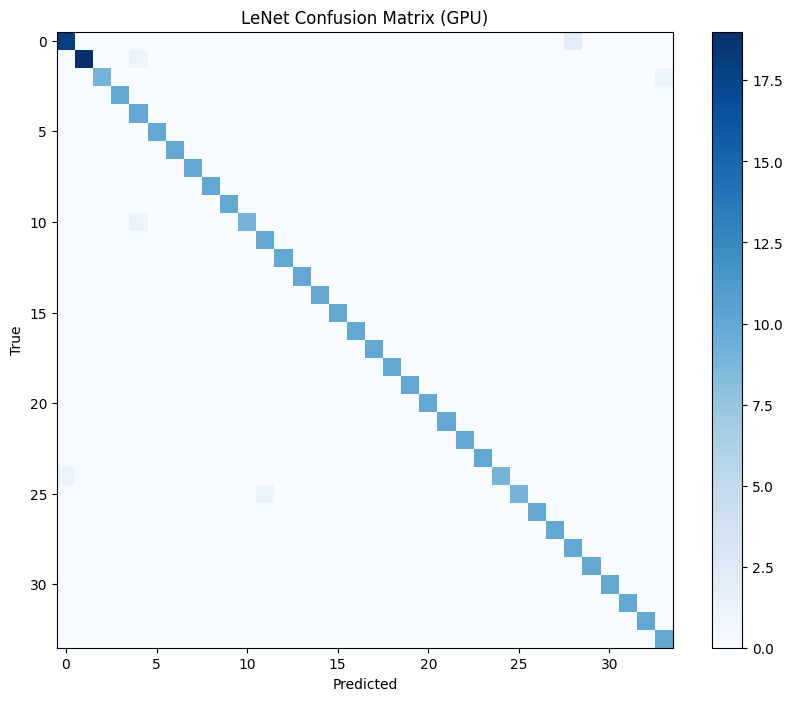

In [321]:
# Cell 16（新增）：混淆矩陣（GPU）
from sklearn.metrics import confusion_matrix

cm_gpu = confusion_matrix(y_test.numpy(), y_pred_gpu)

plt.figure(figsize=(10, 8))
plt.imshow(cm_gpu, cmap="Blues")
plt.title("LeNet Confusion Matrix (GPU)")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

錯誤數量： 7


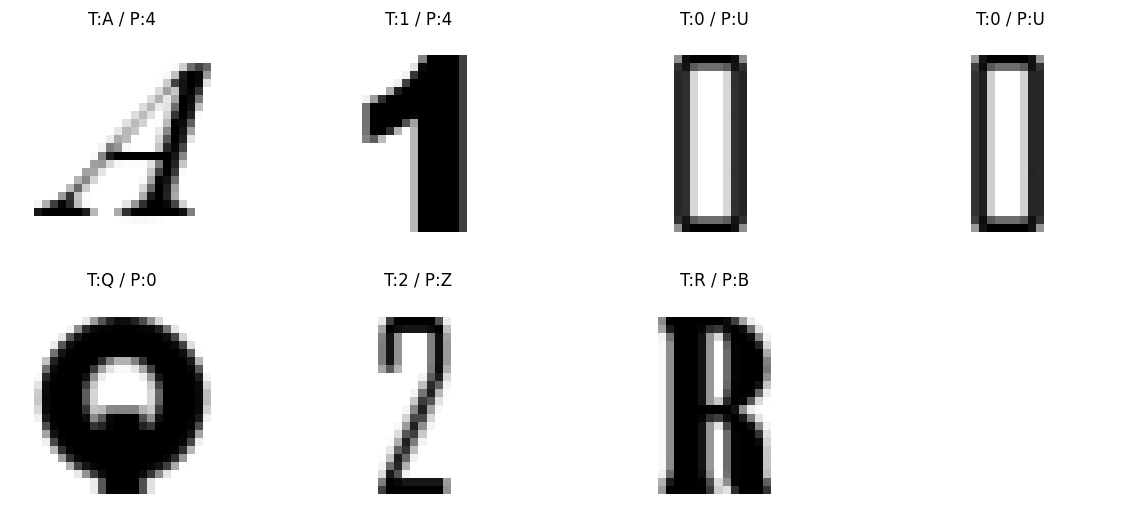

In [322]:
# Cell 17: 找錯誤案例
wrong_idx = np.where(y_pred_gpu != y_test.numpy())[0]

print("錯誤數量：", len(wrong_idx))

plt.figure(figsize=(12, 8))

for i in range(min(12, len(wrong_idx))):
    idx = wrong_idx[i]

    img = X_test[idx].cpu().numpy().reshape(28, 28)
    true_label = label_names[y_test[idx]]
    pred_label = label_names[y_pred_gpu[idx]]

    plt.subplot(3, 4, i + 1)
    plt.imshow(img, cmap="gray")
    plt.title(f"T:{true_label} / P:{pred_label}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [315]:
# error 10， acc 0.972

# model arg* 10000~20000,acc 0.994

# arg* 1e4 ，test acc : 0.991

# arg* 9e3  test acc :